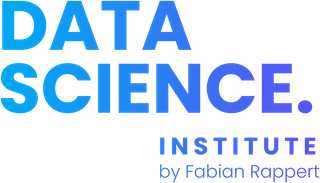

# Inhaltsverzeichnis 

- **Aufgaben zu Requests**
    - **Aufgabe 1**
    - **Aufgabe 2**
    - **Aufgabe 3**
    - **Aufgabe 4**
    - **Aufgabe 5**
    - **Aufgabe 6**


# Aufgaben zu Requests

Gehe auf die Seite https://uselessfacts.jsph.pl/ und versuche zu verstehen, wie die API funktioniert. 

Gib dazu z.B. URLs direkt im Browser ein und schaue dir das Ergebnis an. 

In [1]:
import requests

## Aufgabe 1

- Schreibe eine Funktion, die einen zufälligen Fakt von der Webseite abfragt. 

In [2]:
res = requests.get("https://uselessfacts.jsph.pl/api/v2/facts/random")
print(f"{res.json()}")

{'id': '28e3efb1879b1912140b3a62fb6aad67', 'text': '28% of Africa is classified as wilderness. In North America, its 38%.', 'source': 'djtech.net', 'source_url': 'https://www.djtech.net/humor/shorty_useless_facts.htm', 'language': 'en', 'permalink': 'https://uselessfacts.jsph.pl/api/v2/facts/28e3efb1879b1912140b3a62fb6aad67'}


In [3]:
def get_random_fact(language: str = "de") -> str:
    url = "https://uselessfacts.jsph.pl/api/v2/facts/random"
    link = f"{url}?language={language}"
    headers = {"Accept": "application/json"}
    res = requests.get(link, headers)
    if res.status_code == 200:
        data = res.json()
        try:
            return data["text"]
        except KeyError:
            return "Fact text not found."
    else:
        return f"Error: {res.status_code}"

In [4]:
print(get_random_fact())

Der Soul-Sänger Aloe Blacc heißt eigentlich Egbert Nathaniel Dawkins III


## Aufgabe 2

- Ergänze obige Funktion, so dass man über einen Parameter bestimmen kann, ob man *deutsche* oder *englische* Fakten erhalten will.

In [5]:
print(get_random_fact("en"))
print(get_random_fact("de"))

The Vatican city registered 0 births in 1983
Die größte Goldmünze der Welt hat einen Durchmesser von achtzig Zentimetern und wiegt eine Tonne


## Aufgabe 3

- Ergänze die Funktion weiter, so dass nur Antworten kommen, die im JSON-Format sind.

In [6]:
# ich habe das schon gemacht

________________________________________________________________________________  

Benutze im folgenden die [PoetryDB](https://poetrydb.org) um die Aufgaben zu lösen.

## Aufgabe 4

- Wieviel Gedichte hat Emily Dickinson geschrieben?

In [7]:
def get_poems_by_author(author: str):
    url = f"https://poetrydb.org/author/{author}/title"
    response = requests.get(url)

    if response.status_code == 200:
        poems = response.json()
        print(f"Es gibt {len(poems)} Gedichte von {author}.")
        print()
        print("Diese Gedichte sind:")
        print()
        for poem in poems:
            print(poem["title"])
        return poems
    else:
        return f"Error: {response.status_code}"

In [8]:
get_poems_by_author("Emily Dickinson")

Es gibt 362 Gedichte von Emily Dickinson.

Diese Gedichte sind:

Not at Home to Callers
Defrauded I a Butterfly --
The words the happy say
Summer begins to have the look
The Notice that is called the Spring
Than Heaven more remote,
Which is the best -- the Moon or the Crescent?
The Life we have is very great.
Her Sweet turn to leave the Homestead
We should not mind so small a flower
Nature can do no more
Declaiming Waters none may dread --
The Butterfly's Numidian Gown
I prayed, at first, a little Girl,
So give me back to Death --
I never felt at Home -- Below
Could Hope inspect her Basis
He put the Belt around my life
A full fed Rose on meals of Tint
Success is counted sweetest
I Years had been from Home
Musicians wrestle everywhere
How much the present moment means
Yesterday is History,
Now I knew I lost her --
I noticed People disappeared
Snow beneath whose chilly softness
Absent Place -- an April Day --
Where Thou art -- that -- is Home --
The first Day that I was a Life
They shut 

[{'title': 'Not at Home to Callers'},
 {'title': 'Defrauded I a Butterfly --'},
 {'title': 'The words the happy say'},
 {'title': 'Summer begins to have the look'},
 {'title': 'The Notice that is called the Spring'},
 {'title': 'Than Heaven more remote,'},
 {'title': 'Which is the best -- the Moon or the Crescent?'},
 {'title': 'The Life we have is very great.'},
 {'title': 'Her Sweet turn to leave the Homestead'},
 {'title': 'We should not mind so small a flower'},
 {'title': 'Nature can do no more'},
 {'title': 'Declaiming Waters none may dread --'},
 {'title': "The Butterfly's Numidian Gown"},
 {'title': 'I prayed, at first, a little Girl,'},
 {'title': 'So give me back to Death --'},
 {'title': 'I never felt at Home -- Below'},
 {'title': 'Could Hope inspect her Basis'},
 {'title': 'He put the Belt around my life'},
 {'title': 'A full fed Rose on meals of Tint'},
 {'title': 'Success is counted sweetest'},
 {'title': 'I Years had been from Home'},
 {'title': 'Musicians wrestle every

## Aufgabe 5

- Welches Werk Shakespeares enhält die folgenden Zeilen:

> *The little Love-god lying once asleep,<br>
  Laid by his side his heart-inflaming brand,*   

In [9]:
def find_title_by_lines(author: str, search_text: str) -> str:
    url = f"https://poetrydb.org/author/{author}/author,title,lines"
    response = requests.get(url)

    if response.status_code == 200:
        poems = response.json()
        found_poems = []

        for poem in poems:
            for line in poem["lines"]:
                if search_text.lower() in line.lower():
                    found_poems.append(poem)
                    break

        if found_poems:
            return [poem["title"] for poem in found_poems]
        else:
            return "No poems found with that text"
    else:
        return f"Error: {response.status_code}"

In [10]:
find_title_by_lines("William Shakespeare", "The little Love-god lying once asleep")

['Sonnet 154: The little Love-god lying once asleep']

## Aufgabe 6

Ziel dieser Hausaufgabe ist es, die Grundlagen der API-Paginierung in Python zu verstehen und anzuwenden. Dazu verwenden wir [die größte Sammlung von Open-Source-Hundebildern im Internet](https://dog.ceo/dog-api/).

**Hinweise**:
Da die API keine Rate-Limitierung hat, solltet ihr dennoch respektvoll und verantwortungsbewusst sein, um den Server nicht zu überlasten. **D.h. baue kurze Verzögerung zwischen den API-Anfragen ein**.
Die API-Dokumentation findet ihr [hier](https://github.com/ElliottLandsborough/dog-ceo-api).

Der API-Endpunkt lautet: https://dog.ceo/api/breeds/image/random/

Baut eine Paginierung in euren Python-Code ein, um nur eine bestimmte Anzahl von Hundebildern pro "Seite" zu erhalten. Ihr könnt z.B. 3 Bilder pro Seite als Limit festlegen.

Erstellt eine Schleife in Python, die durch die verschiedenen "Seiten" iteriert und die URLs der Hunde-Bilder für jede Seite ausgibt.

In [11]:
import time

from IPython.display import Image, display

Page 1:
https://images.dog.ceo/breeds/poodle-toy/n02113624_7448.jpg


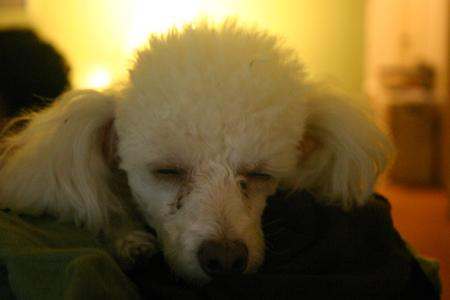

https://images.dog.ceo/breeds/newfoundland/n02111277_2865.jpg


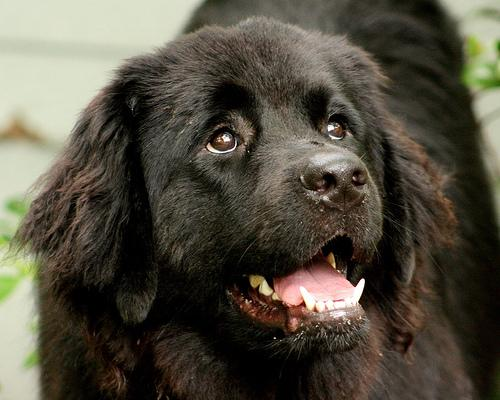

https://images.dog.ceo/breeds/husky/n02110185_9334.jpg


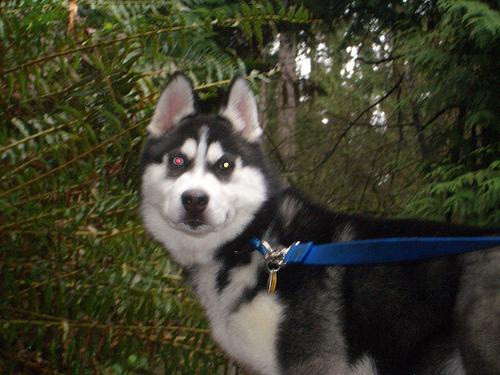

Page 2:
https://images.dog.ceo/breeds/terrier-toy/n02087046_5701.jpg


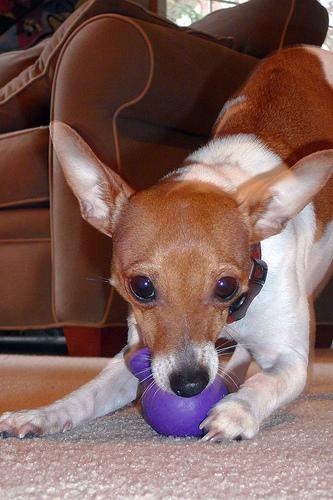

https://images.dog.ceo/breeds/hound-blood/n02088466_8969.jpg


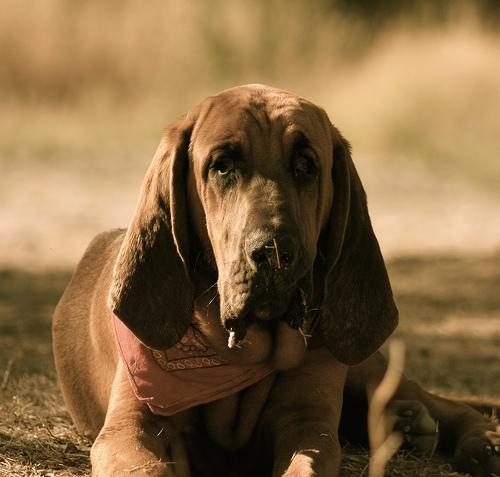

https://images.dog.ceo/breeds/deerhound-scottish/n02092002_109.jpg


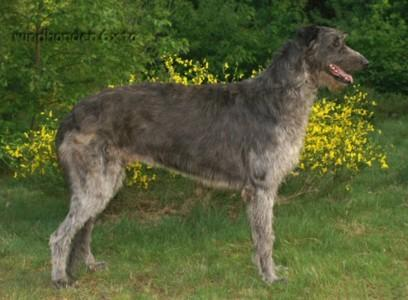

Page 3:
https://images.dog.ceo/breeds/spaniel-blenheim/n02086646_1993.jpg


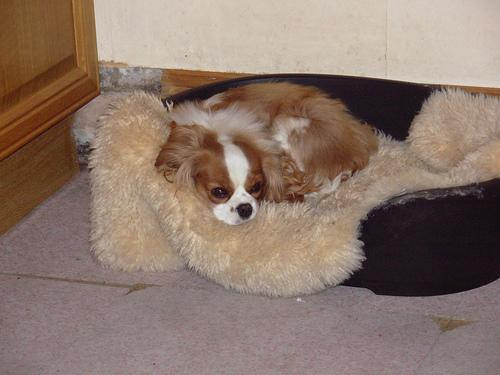

https://images.dog.ceo/breeds/rough-collie/Collie-Rough.jpg


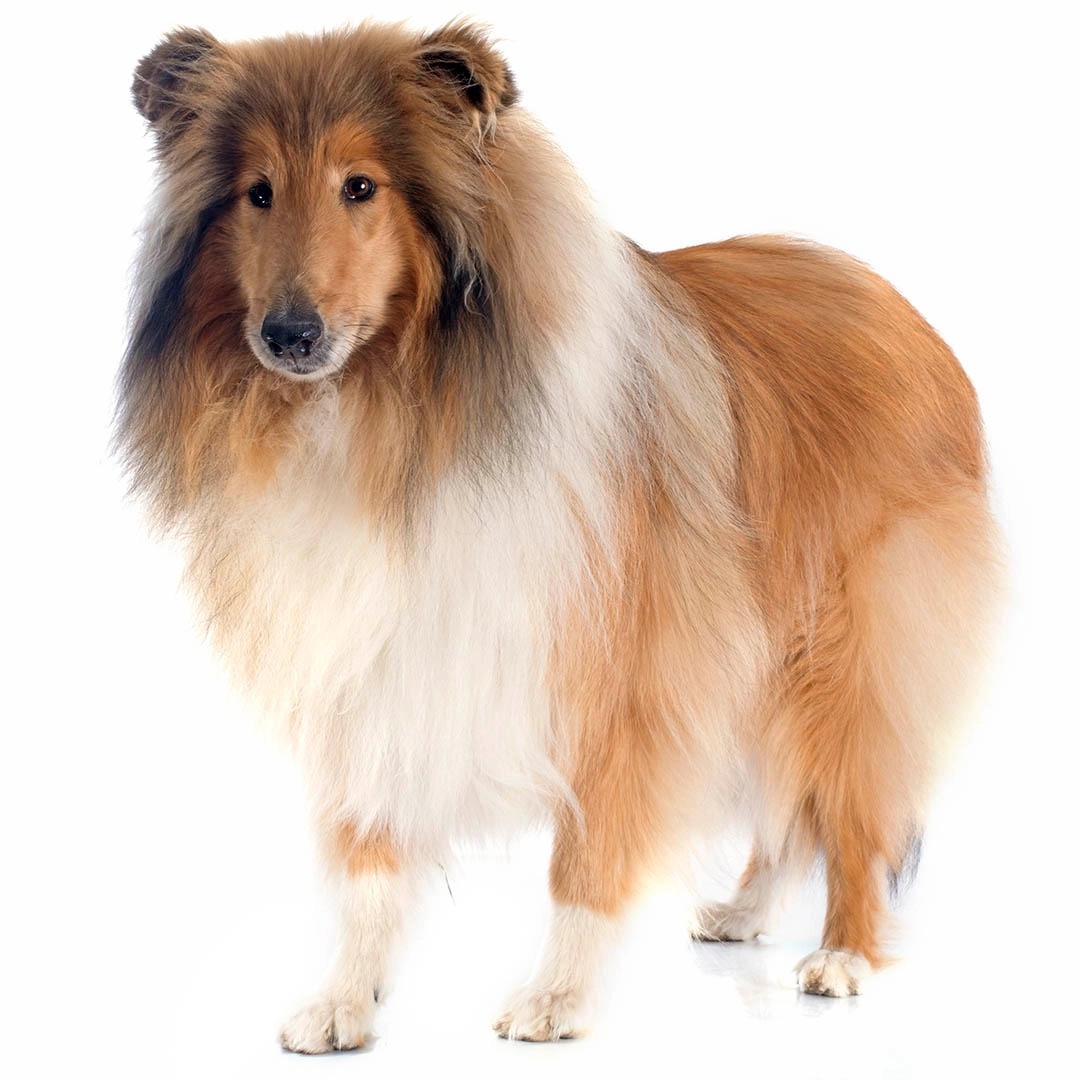

https://images.dog.ceo/breeds/pyrenees/n02111500_7591.jpg


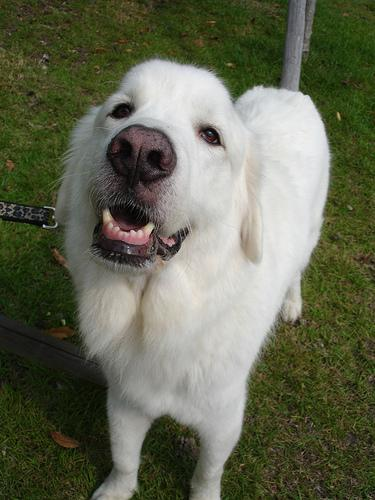

Page 4:
https://images.dog.ceo/breeds/sheepdog-english/n02105641_1411.jpg


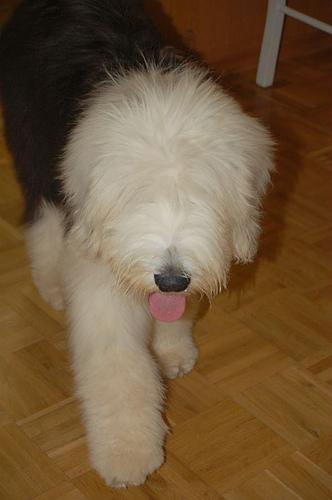

https://images.dog.ceo/breeds/spaniel-blenheim/n02086646_981.jpg


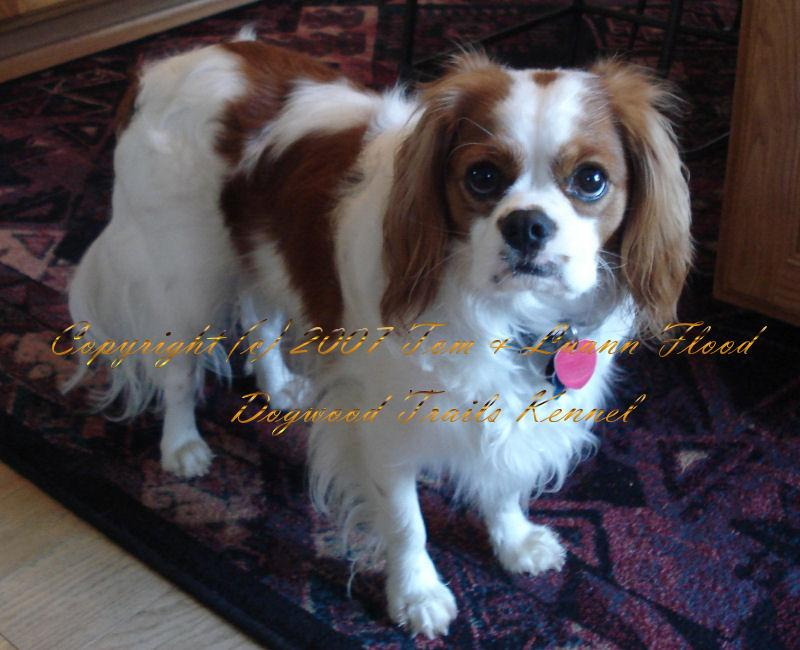

https://images.dog.ceo/breeds/setter-english/n02100735_3194.jpg


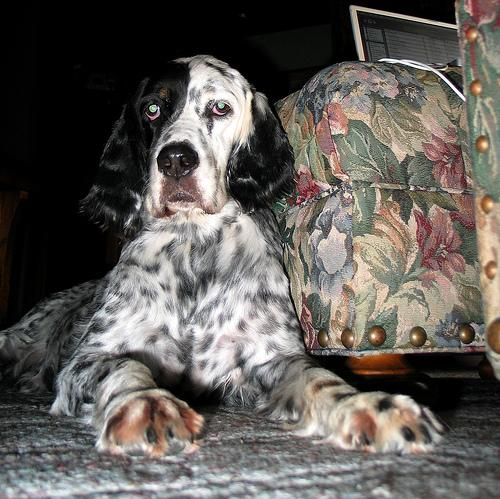

Page 5:
https://images.dog.ceo/breeds/terrier-norfolk/n02094114_4294.jpg


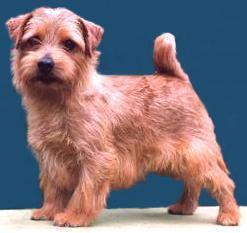

https://images.dog.ceo/breeds/terrier-norwich/n02094258_2730.jpg


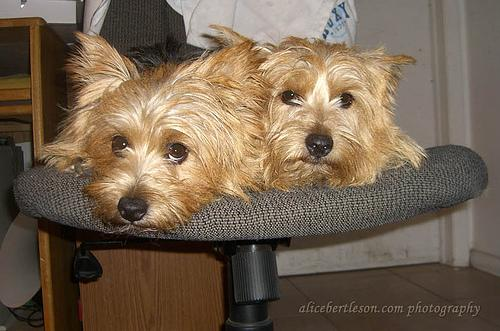

https://images.dog.ceo/breeds/weimaraner/n02092339_748.jpg


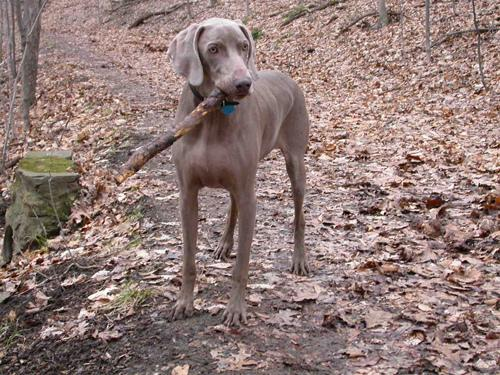

In [12]:
# Basis-URL der API
base_url = "https://dog.ceo/api/breeds/image/random/"

# Anzahl der Bilder pro "Seite"
items_per_page = 3

# Anzahl der Seiten, die wir abrufen möchten
num_pages = 5

pause = 1


for page in range(1, num_pages + 1):
    print(f"Page {page}:")
    response = requests.get(f"{base_url}{items_per_page}")

    if response.status_code == 200:
        data = response.json()
        for url in data["message"]:
            print(url)
            display(Image(url, width=200))

    time.sleep(pause)

**Zusätzliche Aufgabe:**
Zeige die Bilder auf der Konsole an. Dafür gibt es viele Lösungen. Eine sehr einfache Möglichkeit: